<a href="https://colab.research.google.com/github/Alejandra300905/MachineLerningCurso/blob/main/regresion/RegresionPolinomial_PracticaDeAlejandraBustos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/DCDPUAEM/DCDP/blob/main/02-Machine-Learning/notebooks/04-Polinomial-Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ⭕**Práctica**

Construye un modelo de **Regresión Lineal Polinomial** para predecir el **peso** de un pez a partir de las variables predictoras disponibles.

### Objetivo

Aplicar de manera autónoma el flujo completo visto en el ejemplo anterior, ahora con un conjunto de datos más realista.

## Pasos sugeridos

**1. Explora el dataset**
- revisa dimensiones,
- nombres de columnas,
- tipos de datos,
- y posibles valores faltantes.

**2. Selecciona variables**
- define la variable objetivo,
- elige las variables de entrada,
- y decide cómo tratar columnas categóricas como `Species`.

**3. Divide en entrenamiento y prueba**
- usa una partición apropiada para evaluar generalización.

**4. Construye el modelo**
- puedes usar `PolynomialFeatures` + `LinearRegression`,
- o un `Pipeline` para simplificar el proceso.

**5. Entrena el modelo**
- ajusta con el conjunto de entrenamiento.

**6. Evalúa**
- reporta el desempeño en entrenamiento y en prueba,
- compara ambos resultados.

**7. Interpreta**
- ¿el modelo parece generalizar bien?
- ¿hay señales de sobreajuste?
- ¿qué variables podrían estar influyendo más?

### Preguntas de reflexión

- ¿Qué ocurre si aumentas demasiado el grado del polinomio?
- ¿Todas las variables ayudan realmente?
- ¿Qué ventajas tiene usar `Pipeline`?

Puedes usar la siguiente celda vacía para desarrollar tu solución paso a paso.

### Recomendación

Organiza tu trabajo con comentarios como:

- `# Exploración de datos`
- `# Preparación de variables`
- `# División entrenamiento/prueba`
- `# Modelo polinomial`
- `# Evaluación`
- `# Conclusiones`

### Meta final

No se trata solo de que el código funcione.  
También debes poder explicar:

* qué hiciste,  
* por qué lo hiciste,  
* y qué significan tus resultados.

In [1]:
#inicio
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
url = '/content/drive/MyDrive/MachineLearningDataBases/MachineLearningDataBases/fishes.csv'
df = pd.read_csv(url)
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [3]:
df.shape

(159, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


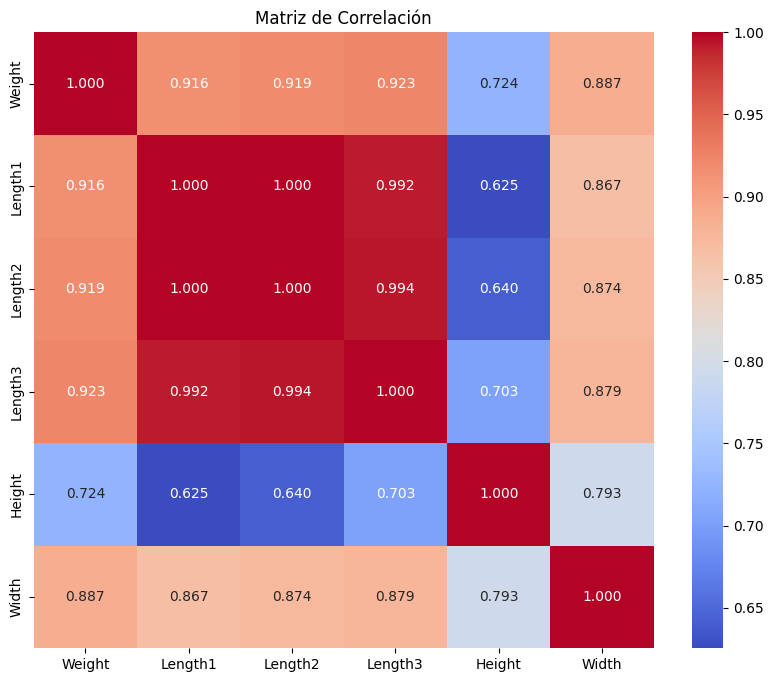

In [5]:
import seaborn as sns
# Seleccionar solo columnas numéricas
df_numerico = df.select_dtypes(include=['float64', 'int64'])
# Calcular matriz de correlación
matriz_correlacion = df_numerico.corr()
# Graficar heatmap
plt.figure(figsize=(10,8))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".3f")
plt.title("Matriz de Correlación")
plt.show()

In [6]:
#Target y caracteristicas
y = df['Weight']
X = df.drop('Weight', axis=1)

In [7]:
X = pd.get_dummies(X, drop_first=True)
X.head()

,Length1,Length2,Length3,Height,Width,Species_Parkki,Species_Perch,Species_Pike,Species_Roach,Species_Smelt,Species_Whitefish
0,23.2,25.4,30.0,11.5200,4.0200,False,False,False,False,False,False
1,24.0,26.3,31.2,12.4800,4.3056,False,False,False,False,False,False
2,23.9,26.5,31.1,12.3778,4.6961,False,False,False,False,False,False
3,26.3,29.0,33.5,12.7300,4.4555,False,False,False,False,False,False
4,26.5,29.0,34.0,12.4440,5.1340,False,False,False,False,False,False


In [8]:
#Dividir entre entrenamiento y prueba
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X,y,train_size=0.8,random_state=42)

In [9]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(127, 11)
(32, 11)
(127,)
(32,)


In [10]:
#Construir modelo
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [11]:
pl = Pipeline([
    ('pf', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])

In [12]:
pl.fit(x_train, y_train)

Pipeline(steps=[('pf', PolynomialFeatures(include_bias=False)),
                ('lr', LinearRegression())])

In [13]:
#entrenar modelo
pl.fit(x_train, y_train)
#Evaluar entrenamiento y prueba
train_score = pl.score(x_train, y_train)
test_score = pl.score(x_test, y_test)
print("R² entrenamiento:", train_score)
print("R² prueba:", test_score)

R² entrenamiento: 0.9911281329082616
R² prueba: 0.9503501740661642


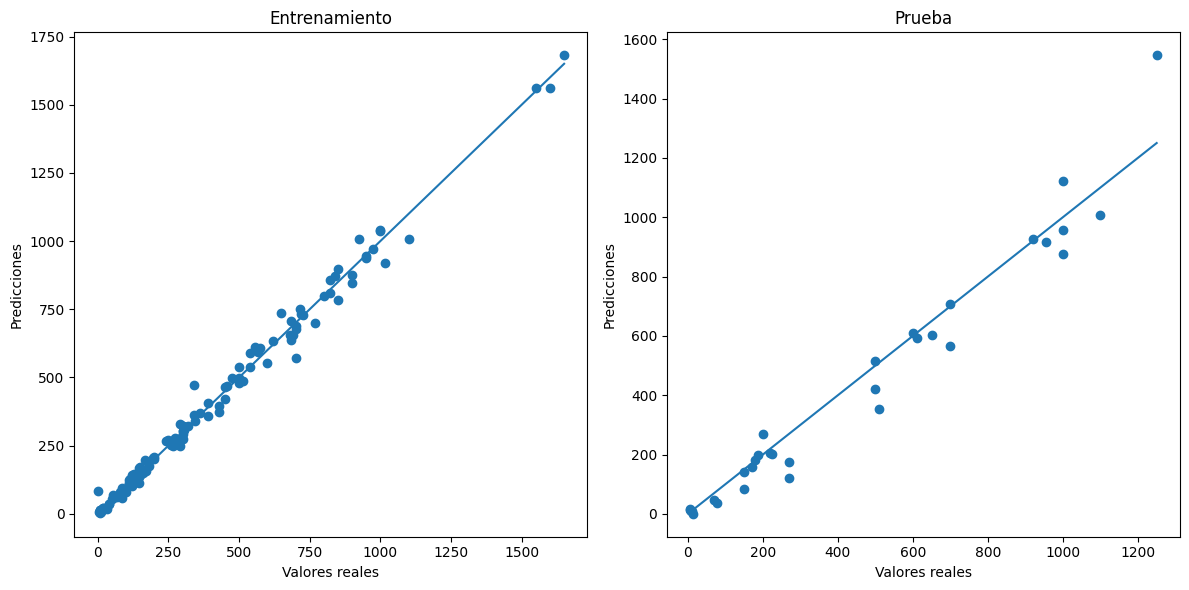

In [14]:
# Predicciones sobre entrenamiento
y_pred_train = pl.predict(x_train)
# Predicciones sobre prueba
y_pred_test = pl.predict(x_test)
# Crear figura con 2 gráficas lado a lado
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.scatter(y_train, y_pred_train)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Entrenamiento")
plt.plot(
    [y_train.min(), y_train.max()],
    [y_train.min(), y_train.max()]
)
#Predicciones sobre prueba
plt.subplot(1,2,2)
plt.scatter(y_test, y_pred_test)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Prueba")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)
plt.tight_layout()
plt.show()

In [15]:
#Regularizacion
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

pl = Pipeline([
    ('pf', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])

In [16]:
#Entrenamiento
pl.fit(x_train, y_train)

train_score = pl.score(x_train, y_train)
test_score = pl.score(x_test, y_test)

print("R² entrenamiento:", train_score)
print("R² prueba:", test_score)

R² entrenamiento: 0.9843591493575445
R² prueba: 0.9847211528776751


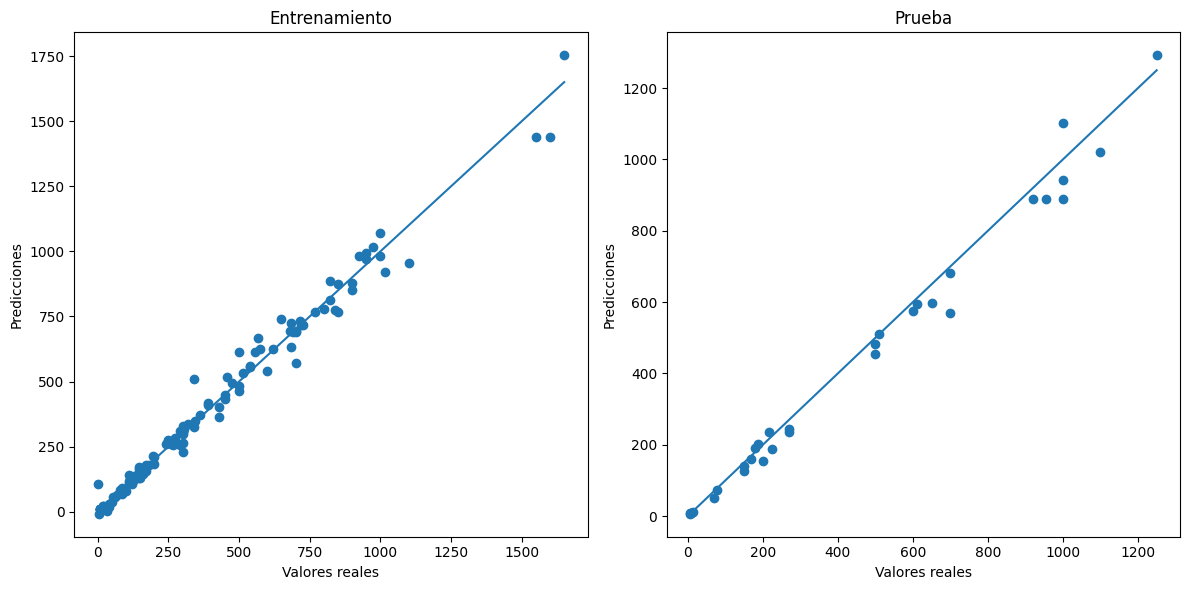

In [17]:
# Predicciones sobre entrenamiento
y_pred_train = pl.predict(x_train)
# Predicciones sobre prueba
y_pred_test = pl.predict(x_test)
# Crear figura con 2 gráficas lado a lado
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.scatter(y_train, y_pred_train)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Entrenamiento")
plt.plot(
    [y_train.min(), y_train.max()],
    [y_train.min(), y_train.max()]
)
#Predicciones sobre prueba
plt.subplot(1,2,2)
plt.scatter(y_test, y_pred_test)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Prueba")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)
plt.tight_layout()
plt.show()